In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / 'data').exists():
    raise FileNotFoundError('Não foi possível localizar a raiz do projeto.')

for candidate in [
    PROJECT_ROOT / 'code',
    PROJECT_ROOT / 'code' / 'revenue',
    PROJECT_ROOT / 'code' / 'tmdb',
]:
    if candidate.exists() and str(candidate.resolve()) not in sys.path:
        sys.path.append(str(candidate.resolve()))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from sklearn.inspection import permutation_importance

from experiment_utils import (
    ARTICLE_FIGURE_SIZES,
    RANDOM_SEED,
    TARGET_CONFIGS,
    apply_article_figure_theme,
    build_best_params_lookup,
    build_model_from_best_params,
    format_metric_mean_std,
    format_metric_value,
    format_summary_display,
    load_feature_matrix,
    load_model_selection_artifacts,
    load_processed_movies,
    load_saved_folds,
    load_saved_stratification_bins,
    show_and_save_current_figure,
)

In [2]:
NOTEBOOK_TARGET_NAME = 'Sem transformação'
NOTEBOOK_IMAGE_PREFIX = '03_analysis_no_transform'
NOTEBOOK_TABLE_PREFIX = NOTEBOOK_IMAGE_PREFIX
TABLES_DIR = PROJECT_ROOT / 'data' / 'revenue_model_selection' / 'error_analysis'
TABLES_DIR.mkdir(parents=True, exist_ok=True)
REVENUE_BAND_LABELS = [
    'Muito baixa receita',
    'Baixa receita',
    'Média receita',
    'Alta receita',
    'Muito alta receita',
]

# **Carregando a Base de Dados**

Este notebook concentra a leitura analítica da versão `Sem transformação` do problema, isto é, com `revenue` mantida diretamente em dólares ao longo do treinamento e da avaliação. A base processada já chega filtrada e codificada, então o foco deixa de ser limpeza de dados e passa a ser a interpretação do desempenho dos modelos e do comportamento do melhor candidato.

Essa escolha preserva a escala original da variável-alvo e facilita a leitura direta de métricas como `RMSE` e `MAE`, mas também expõe o treinamento à forte assimetria típica de arrecadações cinematográficas.


In [3]:
df_movies = load_processed_movies()

In [4]:
df_movies

,id_tmdb,title,runtime,adult,belongs_to_collection,budget,Action,Adventure,Animation,Comedy,...,sv,ta,te,th,tn,tr,uk,ur,zh,revenue
0,552524,Lilo & Stitch,108,0,0,100000000,0,0,0,1,...,0,0,0,0,0,0,0,0,0,610800000
1,950387,A Minecraft Movie,101,0,1,150000000,0,1,0,1,...,0,0,0,0,0,0,0,0,0,947000000
2,1257960,सिकंदर,133,0,0,23500000,1,0,0,0,...,0,0,0,0,0,0,0,0,0,24727058
3,574475,Final Destination Bloodlines,110,0,1,50000000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,229314062
4,1197306,A Working Man,116,0,0,40000000,1,0,0,0,...,0,0,0,0,0,0,0,0,0,98652557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6913,12211,Highlander: Endgame,87,0,1,25000000,1,1,0,0,...,0,0,0,0,0,0,0,0,0,15843608
6914,590706,Jiu Jitsu,102,0,0,23000000,1,0,0,0,...,0,0,0,0,0,0,0,0,0,99924
6915,459616,Alad'2,98,0,1,18900000,0,1,0,1,...,0,0,0,0,0,0,0,0,0,19000000
6916,188207,The Legend of Hercules,99,0,0,70000000,1,1,0,0,...,0,0,0,0,0,0,0,0,0,61279452


# **Folds Reutilizados**

Os folds externos e os cortes de estratificação já foram construídos no notebook `01_fold_generation.ipynb`. Aqui, esses artefatos são apenas recarregados para manter exatamente o mesmo protocolo experimental adotado na seleção inicial de modelos, sem repetir a etapa de construção das partições.

Com isso, toda conclusão obtida neste notebook permanece comparável às demais versões do alvo e às análises complementares desenvolvidas depois.


In [5]:
X, y = load_feature_matrix(df_movies)
_, folds_df, _ = load_saved_folds(df_movies)

# **Comparação entre Modelos de Regressão**

Os resultados da busca em grade já foram salvos no notebook `02_model_grid_search.ipynb`. Nesta etapa, o foco fica na leitura consolidada do desempenho de cada modelo, sempre em `média ± desvio-padrão`, para destacar não apenas o nível médio de erro, mas também a estabilidade entre folds.


## **Seleção do Modelo**

A escolha abaixo usa as métricas agregadas como referência principal. Primeiro aparece um resumo curto do modelo selecionado; depois, os vencedores por métrica e a comparação consolidada entre todos os candidatos, o que ajuda a evitar decisões baseadas em um único indicador isolado.


In [6]:
results_df, predictions_df, summary_df = load_model_selection_artifacts(NOTEBOOK_TARGET_NAME)
best_params_per_model = build_best_params_lookup(results_df)
summary_display_df = format_summary_display(summary_df)
summary_reset_df = summary_df.reset_index()

METRIC_RULES = [
    ('mean_mse', 'menor é melhor'),
    ('mean_rmse', 'menor é melhor'),
    ('mean_mae', 'menor é melhor'),
    ('mean_r2', 'maior é melhor'),
]
METRIC_LABELS = {
    'mean_mse': 'MSE',
    'mean_rmse': 'RMSE',
    'mean_mae': 'MAE',
    'mean_r2': 'R²',
}

def build_metric_winners_table(summary_source_df):
    winner_rows = []

    for metric_name, rule_label in METRIC_RULES:
        if rule_label == 'maior é melhor':
            ordered_df = summary_source_df.sort_values(
                by=[metric_name, 'mean_rmse', 'mean_mae', 'model'],
                ascending=[False, True, True, True]
            )
        else:
            ordered_df = summary_source_df.sort_values(
                by=[metric_name, 'mean_rmse', 'mean_mae', 'model'],
                ascending=[True, True, True, True]
            )

        winner = ordered_df.iloc[0]
        winner_rows.append({
            'metric': metric_name,
            'rule': rule_label,
            'winning_model': winner['model'],
        })

    metric_winners_df = pd.DataFrame(winner_rows)
    winner_counts_df = (
        metric_winners_df['winning_model']
        .value_counts()
        .rename_axis('model')
        .reset_index(name='n_metric_wins')
    )
    winner_metrics_df = (
        metric_winners_df
        .groupby('winning_model')['metric']
        .agg(lambda values: ', '.join(METRIC_LABELS[value] for value in values))
        .rename('metrics_won')
        .reset_index()
        .rename(columns={'winning_model': 'model'})
    )
    winner_counts_df = winner_counts_df.merge(winner_metrics_df, on='model', how='left')
    winner_counts_df = winner_counts_df.merge(
        summary_source_df[['model', 'mean_mse', 'mean_rmse', 'mean_mae', 'mean_r2']],
        on='model',
        how='left'
    )
    winner_counts_df = winner_counts_df.sort_values(
        ['n_metric_wins', 'mean_rmse', 'mean_mae', 'mean_r2', 'model'],
        ascending=[False, True, True, False, True]
    ).reset_index(drop=True)

    return metric_winners_df, winner_counts_df

def build_metric_winners_display(metric_winners_df, summary_source_df):
    summary_lookup_df = summary_source_df.set_index('model')
    display_rows = []

    for row in metric_winners_df.itertuples(index=False):
        metric_suffix = row.metric.replace('mean_', '')
        winner_summary = summary_lookup_df.loc[row.winning_model]
        display_rows.append({
            'Métrica': METRIC_LABELS[row.metric],
            'Regra': row.rule,
            'Modelo vencedor': row.winning_model,
            'Valor (média ± dp)': format_metric_mean_std(
                winner_summary[f'mean_{metric_suffix}'],
                winner_summary[f'std_{metric_suffix}'],
                metric_suffix,
            ),
        })

    return pd.DataFrame(display_rows)

metric_winners_df, winner_counts_df = build_metric_winners_table(summary_reset_df)

best_row = winner_counts_df.iloc[0]
best_target_name = NOTEBOOK_TARGET_NAME
best_model_name = best_row['model']

selected_model_overview_df = pd.DataFrame({
    'Versão do alvo': [best_target_name],
    'Modelo selecionado': [best_model_name],
    'Vitórias em métricas': [int(best_row['n_metric_wins'])],
    'Métricas vencidas': [best_row['metrics_won']],
})
metric_winners_display_df = build_metric_winners_display(metric_winners_df, summary_reset_df)

In [7]:
selected_model_overview_df

,Versão do alvo,Modelo selecionado,Vitórias em métricas,Métricas vencidas
0,Sem transformação,XGBoost Regressor,4,"MSE, RMSE, MAE, R²"


In [8]:
metric_winners_display_df

,Métrica,Regra,Modelo vencedor,Valor (média ± dp)
0,MSE,menor é melhor,XGBoost Regressor,1.39e+16 (± 3.10e+15)
1,RMSE,menor é melhor,XGBoost Regressor,117.32 mi (± 12.95 mi)
2,MAE,menor é melhor,XGBoost Regressor,58.94 mi (± 2.49 mi)
3,R²,maior é melhor,XGBoost Regressor,0.594 (± 0.060)


In [9]:
summary_display_df

MSE  \
Versão do alvo    Modelo                                               
Sem transformação XGBoost Regressor            1.39e+16 (± 3.10e+15)   
                  Random Forest Regressor      1.44e+16 (± 3.00e+15)   
                  Gradient Boosting Regressor  1.46e+16 (± 3.16e+15)   
                  Linear Regression            1.51e+16 (± 3.62e+15)   
                  Decision Tree Regressor      1.71e+16 (± 3.19e+15)   
                  KNN Regressor                1.73e+16 (± 3.59e+15)   
                  Dummy Regressor              3.45e+16 (± 6.79e+15)   
                  SVR                          3.86e+16 (± 7.10e+15)   

                                                                 RMSE  \
Versão do alvo    Modelo                                                
Sem transformação XGBoost Regressor            117.32 mi (± 12.95 mi)   
                  Random Forest Regressor      119.31 mi (± 12.50 mi)   
                  Gradient Boosting Regressor  120.15 mi (± 12.87 mi)   
                  Linear Regression            122.18 mi (± 14.59 mi)   
                  Decision Tree Regressor      130.44 mi (± 12.01 mi)   
                  KNN Regressor                130.87 mi (± 13.85 mi)   
                  Dummy Regressor              184.99 mi (± 18.95 mi)   
                  SVR                          195.71 mi (± 18.74 mi)   

                                                                 MAE  \
Versão do alvo    Modelo                                               
Sem transformação XGBoost Regressor             58.94 mi (± 2.49 mi)   
                  Random Forest Regressor       59.53 mi (± 2.33 mi)   
                  Gradient Boosting Regressor   59.19 mi (± 2.67 mi)   
                  Linear Regression             63.63 mi (± 2.56 mi)   
                  Decision Tree Regressor       64.03 mi (± 1.94 mi)   
                  KNN Regressor                 66.96 mi (± 3.60 mi)   
                  Dummy Regressor              104.67 mi (± 3.15 mi)   
                  SVR                           86.55 mi (± 3.11 mi)   

                                                             R²  
Versão do alvo    Modelo                                         
Sem transformação XGBoost Regressor             0.594 (± 0.060)  
                  Random Forest Regressor       0.579 (± 0.068)  
                  Gradient Boosting Regressor   0.571 (± 0.086)  
                  Linear Regression             0.562 (± 0.054)  
                  Decision Tree Regressor       0.494 (± 0.097)  
                  KNN Regressor                 0.497 (± 0.057)  
                  Dummy Regressor              -0.000 (± 0.001)  
                  SVR                          -0.121 (± 0.018)

## **Reconstrução para as Análises Complementares**

O modelo selecionado é reajustado em cada partição apenas para viabilizar as análises complementares, como inspeção de erros e importância por permutação. O objetivo aqui não é repetir a comparação entre modelos, mas reconstruir um fluxo coerente para interpretar como o melhor regressor se comporta em diferentes subconjuntos do experimento.


In [10]:
best_model_predictions_df = (
    predictions_df.loc[predictions_df['model'] == best_model_name]
    .sort_values(['fold', 'row_index'])
    .reset_index(drop=True)
)

all_best_models = []

for idx, row in folds_df.iterrows():
    train_idx = row['train_index']
    test_idx = row['test_index']

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    y_train_model = TARGET_CONFIGS[best_target_name]['forward'](y_train)
    y_test_model = TARGET_CONFIGS[best_target_name]['forward'](y_test)

    model = build_model_from_best_params(
        best_model_name,
        best_params_per_model[best_target_name][best_model_name][idx]
    )
    model.fit(X_train, y_train_model)

    all_best_models.append((model, X_test.copy(), y_test_model.copy()))

# **Análise de Erros do Modelo Selecionado**

A leitura abaixo combina uma visão geral dos resíduos com a segmentação por quartis de receita real. Assim, além de inspecionar dispersão, viés e casos extremos, o notebook também mostra em quais faixas de faturamento a versão `Sem transformação` se comporta melhor ou pior.

A ênfase aqui permanece apenas na interpretação desta versão do alvo, sem contrastá-la com a alternativa.


In [11]:
apply_article_figure_theme()
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

current_model_label = f'{best_model_name} | {best_target_name}'

error_analysis_df = best_model_predictions_df.copy()
error_analysis_df['signed_percentage_error'] = np.where(
    error_analysis_df['y_true'] != 0,
    100 * error_analysis_df['residual'] / error_analysis_df['y_true'],
    np.nan,
)


def format_currency_millions(value):
    if pd.isna(value):
        return '-'
    return f'US$ {value / 1_000_000:,.2f} mi'


def format_percentage(value):
    if pd.isna(value):
        return '-'
    return f'{value:.1f}%'


def millions_formatter(value, _position):
    return f'US$ {value / 1_000_000:,.0f} mi'


def apply_revenue_bands(df, bins):
    result = df.copy()
    result['faixa_receita'] = pd.cut(
        result['y_true'],
        bins=bins,
        labels=REVENUE_BAND_LABELS,
        include_lowest=True,
    )
    result['faixa_receita'] = pd.Categorical(
        result['faixa_receita'],
        categories=REVENUE_BAND_LABELS,
        ordered=True,
    )
    return result


def summarize_errors_by_band(df, group_cols=None):
    group_cols = list(group_cols or [])
    grouped = (
        df.groupby(group_cols + ['faixa_receita'], observed=False)
        .agg(
            quantidade_filmes=('row_index', 'size'),
            receita_minima=('y_true', 'min'),
            receita_maxima=('y_true', 'max'),
            mae_medio=('abs_error', 'mean'),
            mse=('residual', lambda values: np.mean(np.square(values))),
            residuo_medio=('residual', 'mean'),
            mediana_erro_absoluto=('abs_error', 'median'),
            percentual_subestimados=('residual', lambda values: (values > 0).mean() * 100),
            percentual_superestimados=('residual', lambda values: (values < 0).mean() * 100),
        )
        .reset_index()
    )
    grouped['rmse'] = np.sqrt(grouped.pop('mse'))
    return grouped


def build_display_table(df, monetary_columns, percentage_columns):
    display_df = df.copy()
    for column in monetary_columns:
        display_df[column] = display_df[column].map(format_currency_millions)
    for column in percentage_columns:
        display_df[column] = display_df[column].map(format_percentage)
    return display_df


def save_table_versions(df, stem, monetary_columns, percentage_columns):
    raw_path = TABLES_DIR / f'{stem}_raw.csv'
    formatted_path = TABLES_DIR / f'{stem}_formatado.csv'
    df.to_csv(raw_path, index=False)
    build_display_table(
        df,
        monetary_columns=monetary_columns,
        percentage_columns=percentage_columns,
    ).to_csv(formatted_path, index=False)
    return raw_path, formatted_path


PLOT_COLORS = {
    'blue': '#4c6a92',
    'navy': '#2f6690',
    'red': '#8c1c13',
    'text': '#243746',
}
BAND_PALETTE = {
    'Muito baixa receita': '#b8ddd4',
    'Baixa receita': '#8fc8bb',
    'Média receita': '#5fb3b3',
    'Alta receita': '#3f88c5',
    'Muito alta receita': '#225ea8',
}


def style_axis(ax, xlabel, ylabel, *, xrotation=0, grid_axis='both'):
    ax.set_xlabel(xlabel, fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)
    ax.set_ylabel(ylabel, fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)
    ax.tick_params(axis='x', labelsize=ARTICLE_FIGURE_SIZES['tick'])
    ax.tick_params(axis='y', labelsize=ARTICLE_FIGURE_SIZES['tick'])
    plt.setp(ax.get_xticklabels(), rotation=xrotation, ha='right' if xrotation else 'center')
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('semibold')
    if grid_axis == 'both':
        ax.grid(True, linestyle='--', alpha=0.28)
    else:
        ax.grid(axis=grid_axis, linestyle='--', alpha=0.28)
    sns.despine(ax=ax)


def add_bar_value_labels(ax, values):
    values = list(values)
    offset = max(values) * 0.015 if values else 0
    for i, value in enumerate(values):
        ax.text(
            i,
            value + offset,
            format_currency_millions(value),
            ha='center',
            va='bottom',
            fontsize=ARTICLE_FIGURE_SIZES['annotation_small'],
            fontweight='semibold',
            color=PLOT_COLORS['text'],
        )


def style_band_legend(legend):
    if legend is None:
        return
    frame = legend.get_frame()
    frame.set_edgecolor('#c7c7c7')
    frame.set_linewidth(1.0)
    frame.set_alpha(0.96)
    for handle in legend.legend_handles:
        if hasattr(handle, 'set_edgecolor'):
            handle.set_edgecolor(PLOT_COLORS['text'])
        if hasattr(handle, 'set_linewidths'):
            handle.set_linewidths([0.9])
        if hasattr(handle, 'set_sizes'):
            handle.set_sizes([38])

## **Visão Geral dos Resíduos**

Antes de segmentar o problema por quartis de receita, vale observar o comportamento agregado das previsões. Os painéis abaixo mostram alinhamento entre valores reais e previstos, distribuição dos resíduos e a presença de desvios sistemáticos ao longo da escala de faturamento.


Figura: Análise de erros do melhor modelo (painéis: valores reais vs preditos, distribuição dos resíduos e resíduos vs predições)


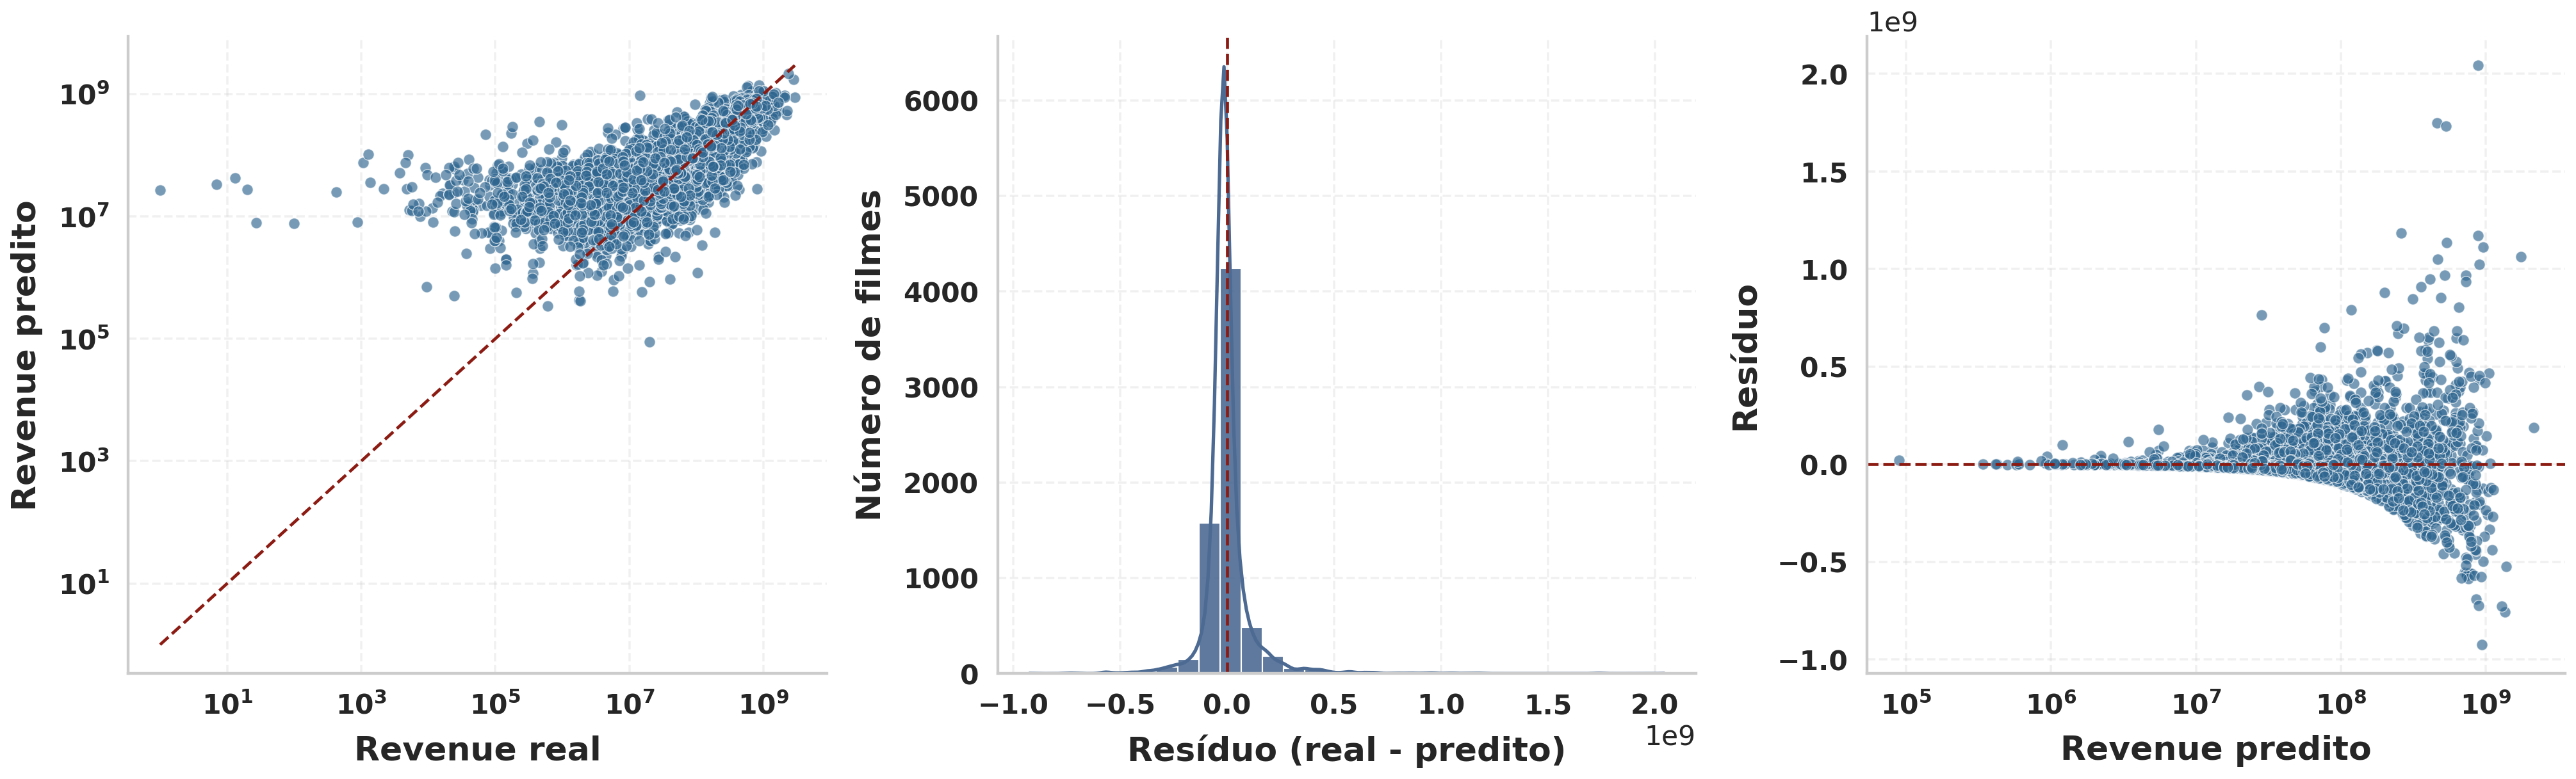

PosixPath('/home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina/trabalho_pratico_1/code/revenue/images/03_analysis_no_transform_analise_de_erros_melhor_modelo.png')

In [12]:
figure_title = (
    'Análise de erros do melhor modelo '
    '(painéis: valores reais vs preditos, distribuição dos resíduos e resíduos vs predições)'
)
apply_article_figure_theme()
fig, axes = plt.subplots(1, 3, figsize=(24, 7.5))

max_axis_value = max(error_analysis_df['y_true'].max(), error_analysis_df['y_pred'].max())
min_axis_value = max(min(error_analysis_df['y_true'].min(), error_analysis_df['y_pred'].min()), 1)

sns.scatterplot(
    data=error_analysis_df,
    x='y_true',
    y='y_pred',
    color='#2f6690',
    alpha=0.65,
    s=55,
    ax=axes[0]
)
axes[0].plot([min_axis_value, max_axis_value], [min_axis_value, max_axis_value], linestyle='--', color='#8c1c13', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Revenue real', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)
axes[0].set_ylabel('Revenue predito', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)

sns.histplot(
    error_analysis_df['residual'],
    bins=30,
    kde=True,
    color='#4c6a92',
    edgecolor='white',
    linewidth=0.9,
    alpha=0.9,
    ax=axes[1]
)
axes[1].axvline(0, linestyle='--', color='#8c1c13', linewidth=2)
axes[1].set_xlabel('Resíduo (real - predito)', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)
axes[1].set_ylabel('Número de filmes', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)

sns.scatterplot(
    data=error_analysis_df,
    x='y_pred',
    y='residual',
    color='#2f6690',
    alpha=0.65,
    s=55,
    ax=axes[2]
)
axes[2].axhline(0, linestyle='--', color='#8c1c13', linewidth=2)
axes[2].set_xscale('log')
axes[2].set_xlabel('Revenue predito', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)
axes[2].set_ylabel('Resíduo', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)

for ax in axes:
    ax.tick_params(axis='x', labelsize=ARTICLE_FIGURE_SIZES['tick'])
    ax.tick_params(axis='y', labelsize=ARTICLE_FIGURE_SIZES['tick'])
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('semibold')
    ax.grid(True, linestyle='--', alpha=0.28)
    sns.despine(ax=ax)

plt.tight_layout()
show_and_save_current_figure(
    f'{NOTEBOOK_IMAGE_PREFIX}_analise_de_erros_melhor_modelo',
    notebook_title=figure_title,
)

## **Faixas de Receita Baseadas na Estratificação dos Folds**

As faixas abaixo reutilizam exatamente os mesmos cortes de receita definidos na estratificação dos folds, preservando o mesmo critério adotado ao longo do protocolo experimental. Com isso, a análise de erros por faixa permanece alinhada à separação entre filmes de menor e maior arrecadação usada desde a construção das partições.


In [13]:
revenue_bins = load_saved_stratification_bins()
if len(revenue_bins) - 1 != len(REVENUE_BAND_LABELS):
    raise ValueError('Os bins salvos da estratificação não correspondem à quantidade de faixas configurada no notebook.')

error_analysis_df = apply_revenue_bands(error_analysis_df, revenue_bins)

band_metrics_raw_df = (
    summarize_errors_by_band(error_analysis_df)
    .sort_values('faixa_receita')
    .reset_index(drop=True)
)

band_metrics_display_df = build_display_table(
    band_metrics_raw_df,
    monetary_columns=[
        'receita_minima',
        'receita_maxima',
        'mae_medio',
        'rmse',
        'residuo_medio',
        'mediana_erro_absoluto',
    ],
    percentage_columns=['percentual_subestimados', 'percentual_superestimados'],
).rename(columns={
    'faixa_receita': 'Faixa de receita',
    'quantidade_filmes': 'Quantidade de filmes',
    'receita_minima': 'Receita mínima',
    'receita_maxima': 'Receita máxima',
    'mae_medio': 'MAE médio',
    'rmse': 'RMSE',
    'residuo_medio': 'Resíduo médio',
    'mediana_erro_absoluto': 'Mediana do erro absoluto',
    'percentual_subestimados': '% de subestimação',
    'percentual_superestimados': '% de superestimação',
})

band_metrics_raw_path, band_metrics_display_path = save_table_versions(
    band_metrics_raw_df,
    stem=f'{NOTEBOOK_TABLE_PREFIX}_metricas_por_faixa',
    monetary_columns=[
        'receita_minima',
        'receita_maxima',
        'mae_medio',
        'rmse',
        'residuo_medio',
        'mediana_erro_absoluto',
    ],
    percentage_columns=['percentual_subestimados', 'percentual_superestimados'],
)

print('Intervalos de receita reutilizados da estratificação dos folds:')
for label, left_edge, right_edge in zip(REVENUE_BAND_LABELS, revenue_bins[:-1], revenue_bins[1:]):
    print(f'- {label}: de {format_currency_millions(left_edge)} até {format_currency_millions(right_edge)}')

print()
print(f'Modelo analisado: {current_model_label}')
print('Tabela final por faixa de receita:')
display(band_metrics_display_df)

print()
print('Arquivos salvos:')
print(f'- {band_metrics_raw_path}')
print(f'- {band_metrics_display_path}')

Intervalos de receita reutilizados da estratificação dos folds:
- Muito baixa receita: de US$ 0.00 mi até US$ 7.09 mi
- Baixa receita: de US$ 7.09 mi até US$ 22.46 mi
- Média receita: de US$ 22.46 mi até US$ 52.82 mi
- Alta receita: de US$ 52.82 mi até US$ 134.08 mi
- Muito alta receita: de US$ 134.08 mi até US$ 2,923.71 mi

Modelo analisado: XGBoost Regressor | Sem transformação
Tabela final por faixa de receita:


,Faixa de receita,Quantidade de filmes,Receita mínima,Receita máxima,MAE médio,Resíduo médio,Mediana do erro absoluto,% de subestimação,% de superestimação,RMSE
0,Muito baixa receita,1384,US$ 0.00 mi,US$ 7.09 mi,US$ 26.50 mi,US$ -26.23 mi,US$ 19.69 mi,7.4%,92.6%,US$ 39.45 mi
1,Baixa receita,1383,US$ 7.10 mi,US$ 22.44 mi,US$ 32.40 mi,US$ -31.14 mi,US$ 24.58 mi,11.1%,88.9%,US$ 52.08 mi
2,Média receita,1384,US$ 22.47 mi,US$ 52.80 mi,US$ 31.00 mi,US$ -23.51 mi,US$ 20.60 mi,28.4%,71.6%,US$ 49.59 mi
3,Alta receita,1383,US$ 52.90 mi,US$ 134.04 mi,US$ 41.33 mi,US$ -2.60 mi,US$ 30.72 mi,59.0%,41.0%,US$ 62.22 mi
4,Muito alta receita,1384,US$ 134.10 mi,"US$ 2,923.71 mi",US$ 163.44 mi,US$ 83.54 mi,US$ 112.53 mi,71.7%,28.3%,US$ 242.82 mi



Arquivos salvos:
- /home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina/trabalho_pratico_1/data/revenue_model_selection/error_analysis/03_analysis_no_transform_metricas_por_faixa_raw.csv
- /home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina/trabalho_pratico_1/data/revenue_model_selection/error_analysis/03_analysis_no_transform_metricas_por_faixa_formatado.csv


## **Gráficos de Erro por Faixa de Receita**

Os gráficos abaixo ajudam a distinguir magnitude média dos erros, dispersão das previsões e padrões de viés ao longo da escala de receita. Em conjunto, eles deixam mais claro se o modelo falha de forma homogênea ou se concentra dificuldade em uma região específica do problema.


Figura: MAE por faixa de receita


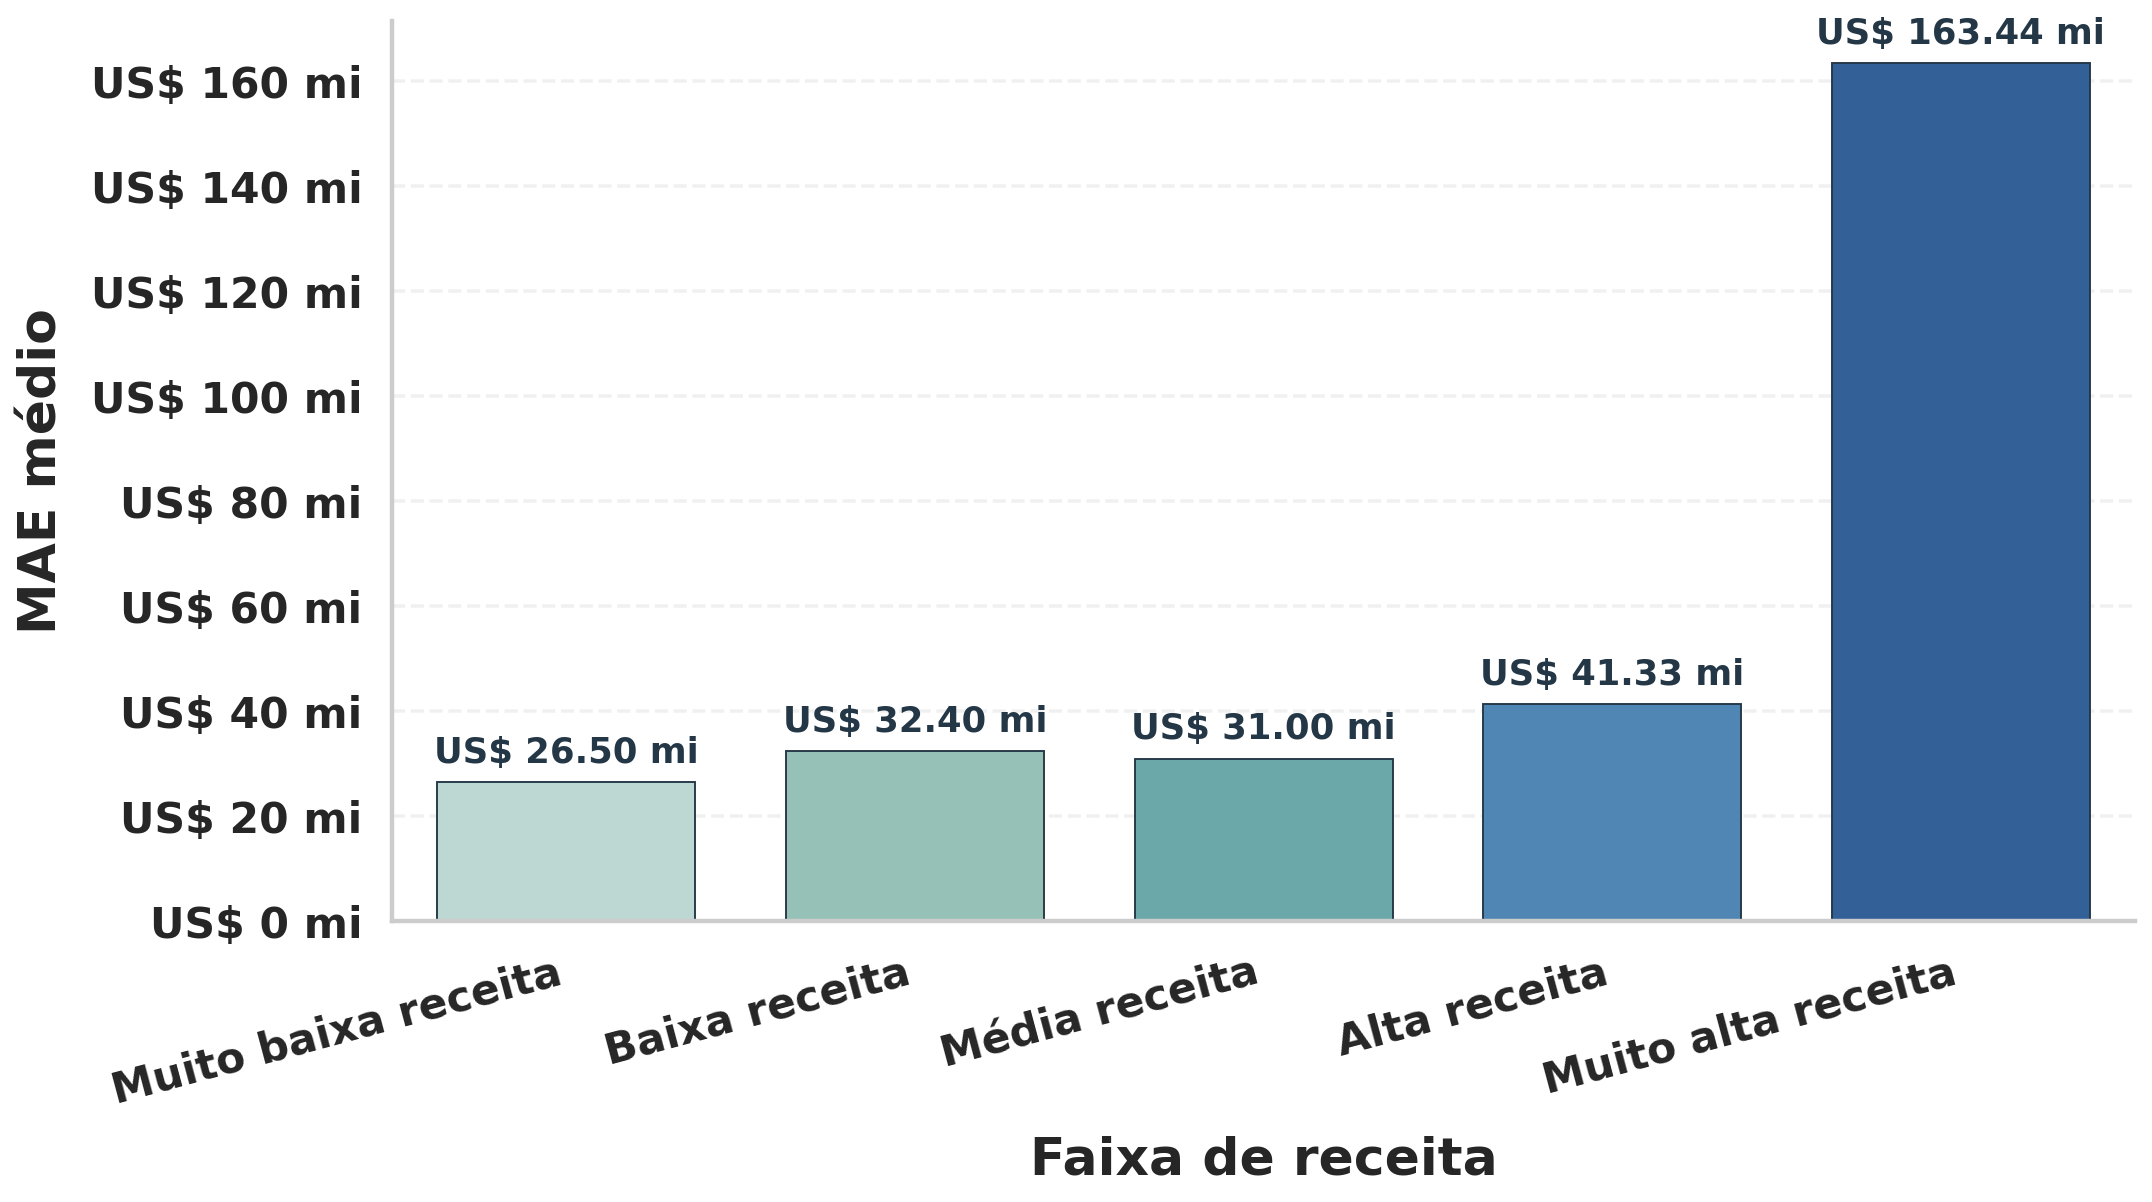

Figura: Distribuição do erro absoluto por faixa de receita


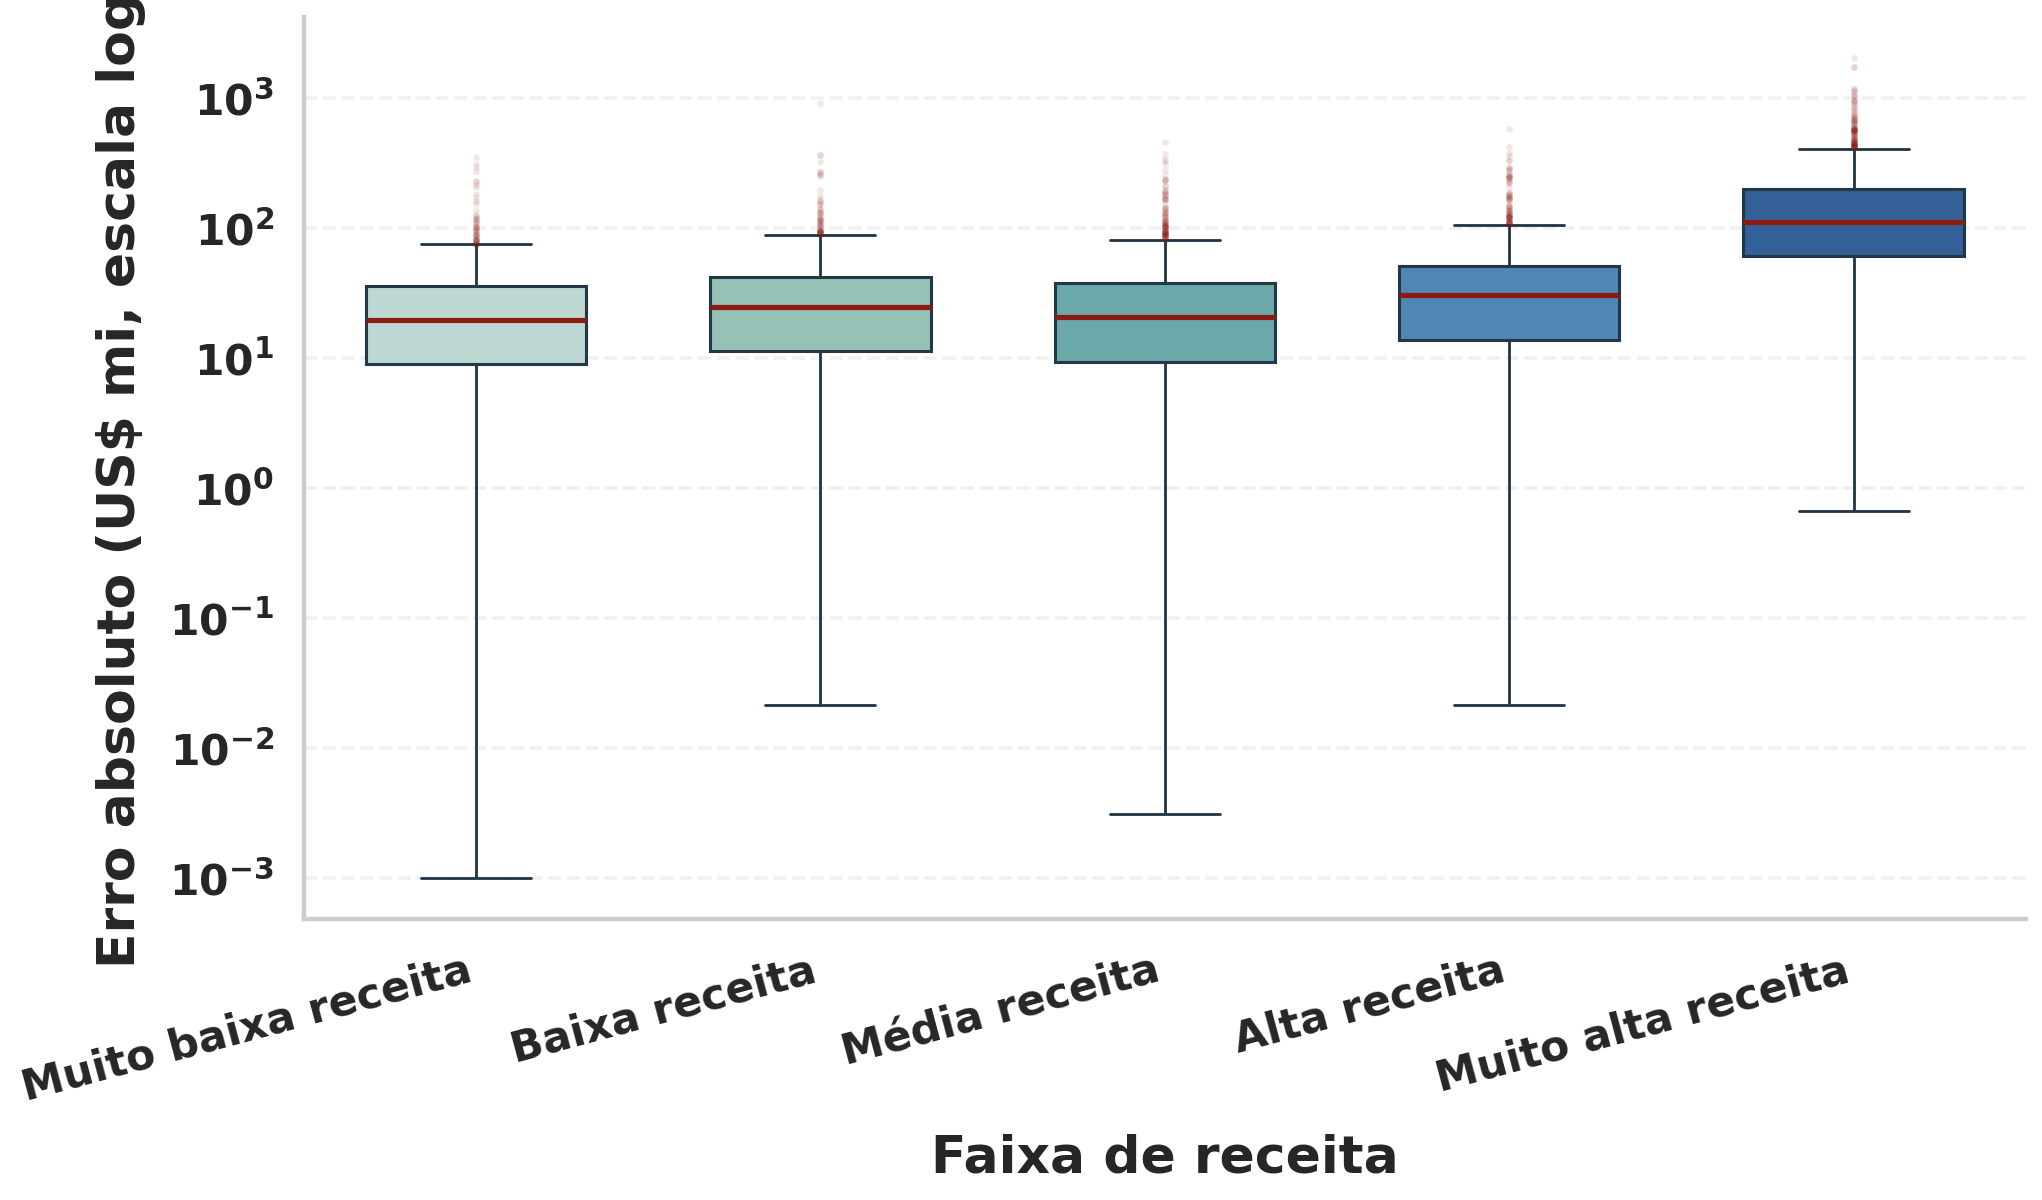

Figura: Valores reais vs preditos por faixa de receita


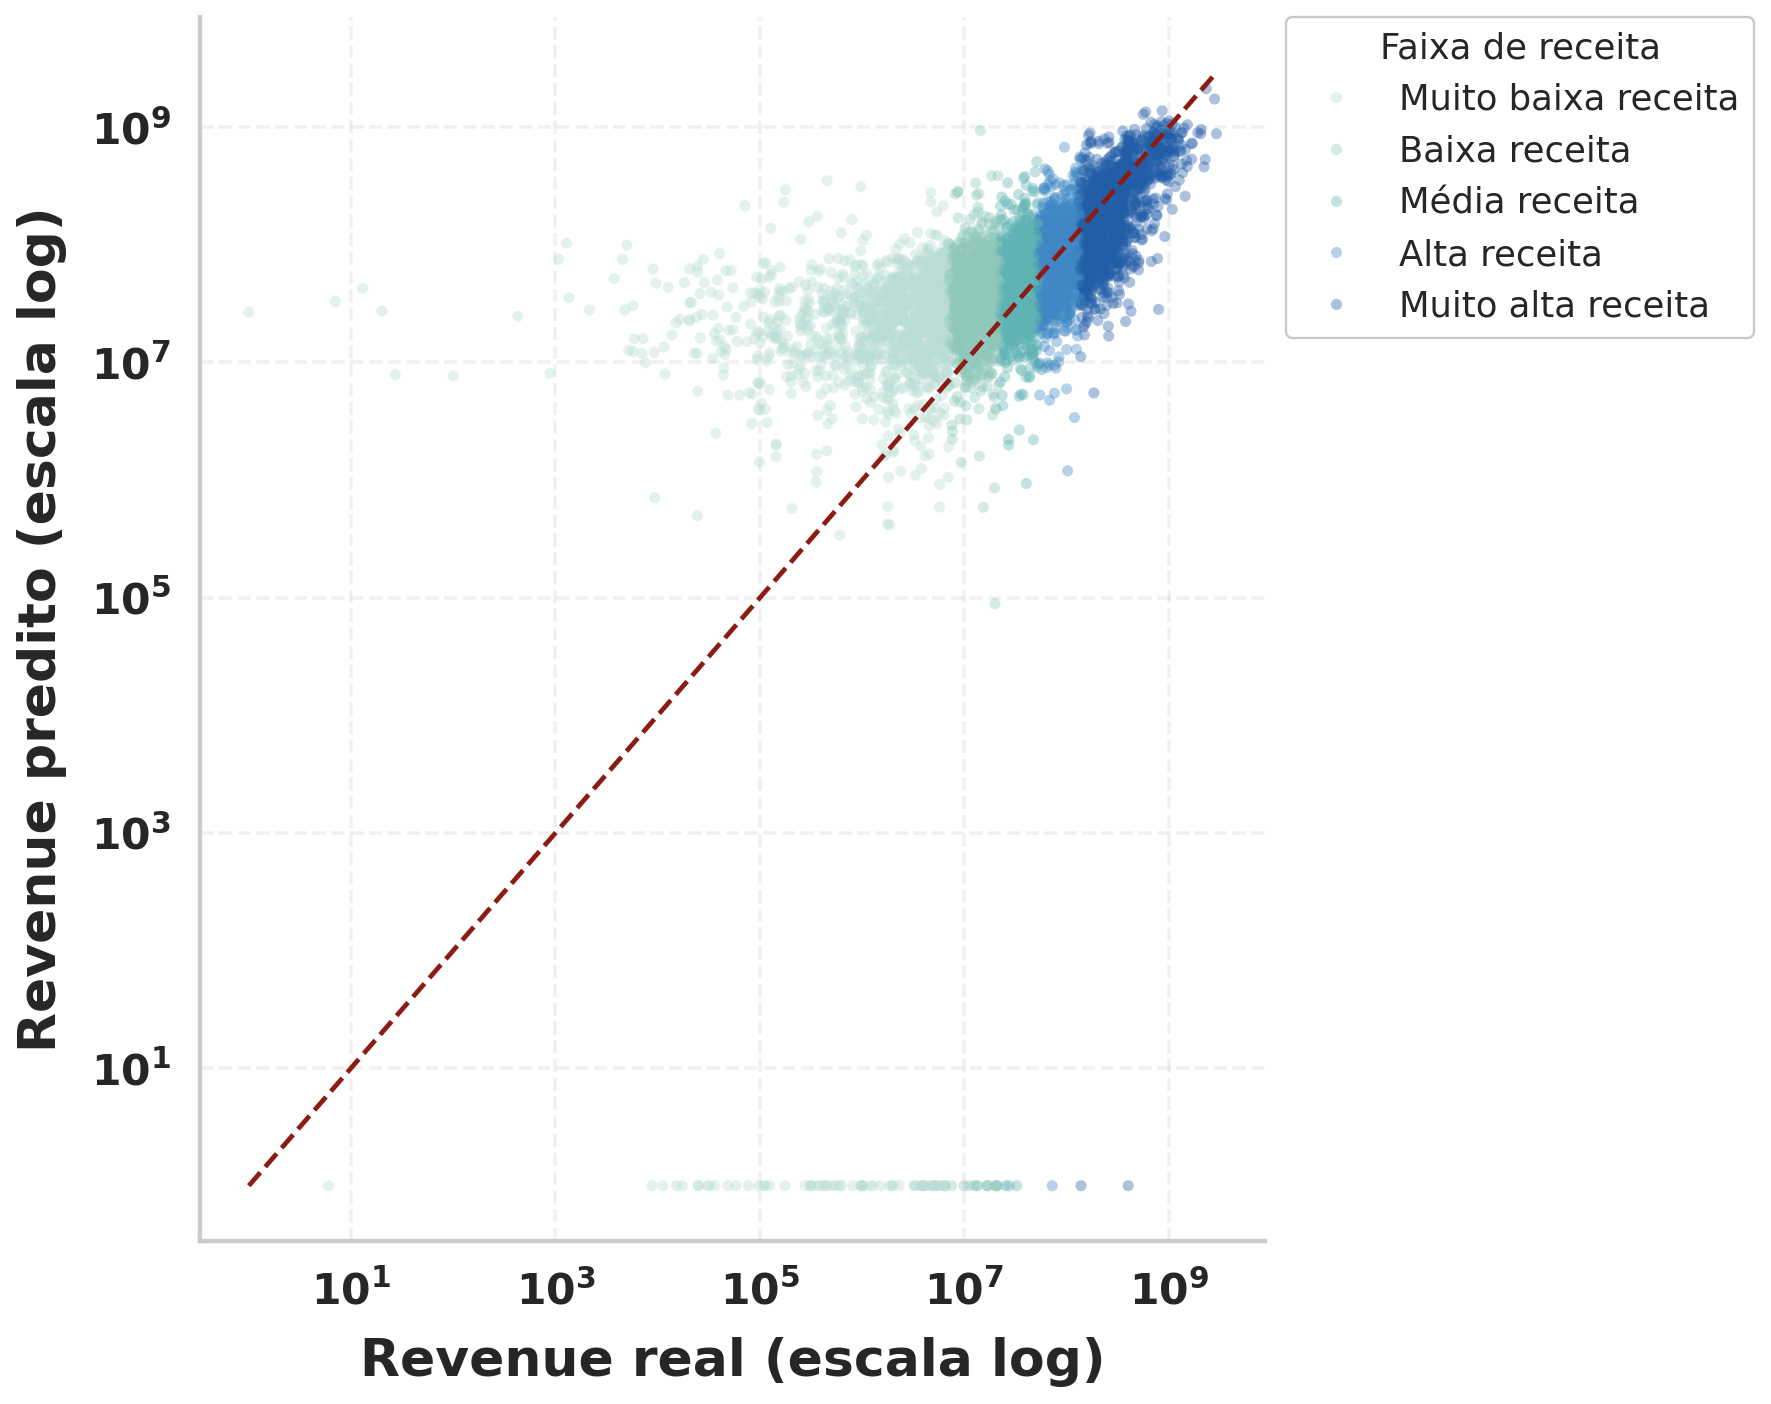

Figura: Resíduos em função da receita real por faixa de receita


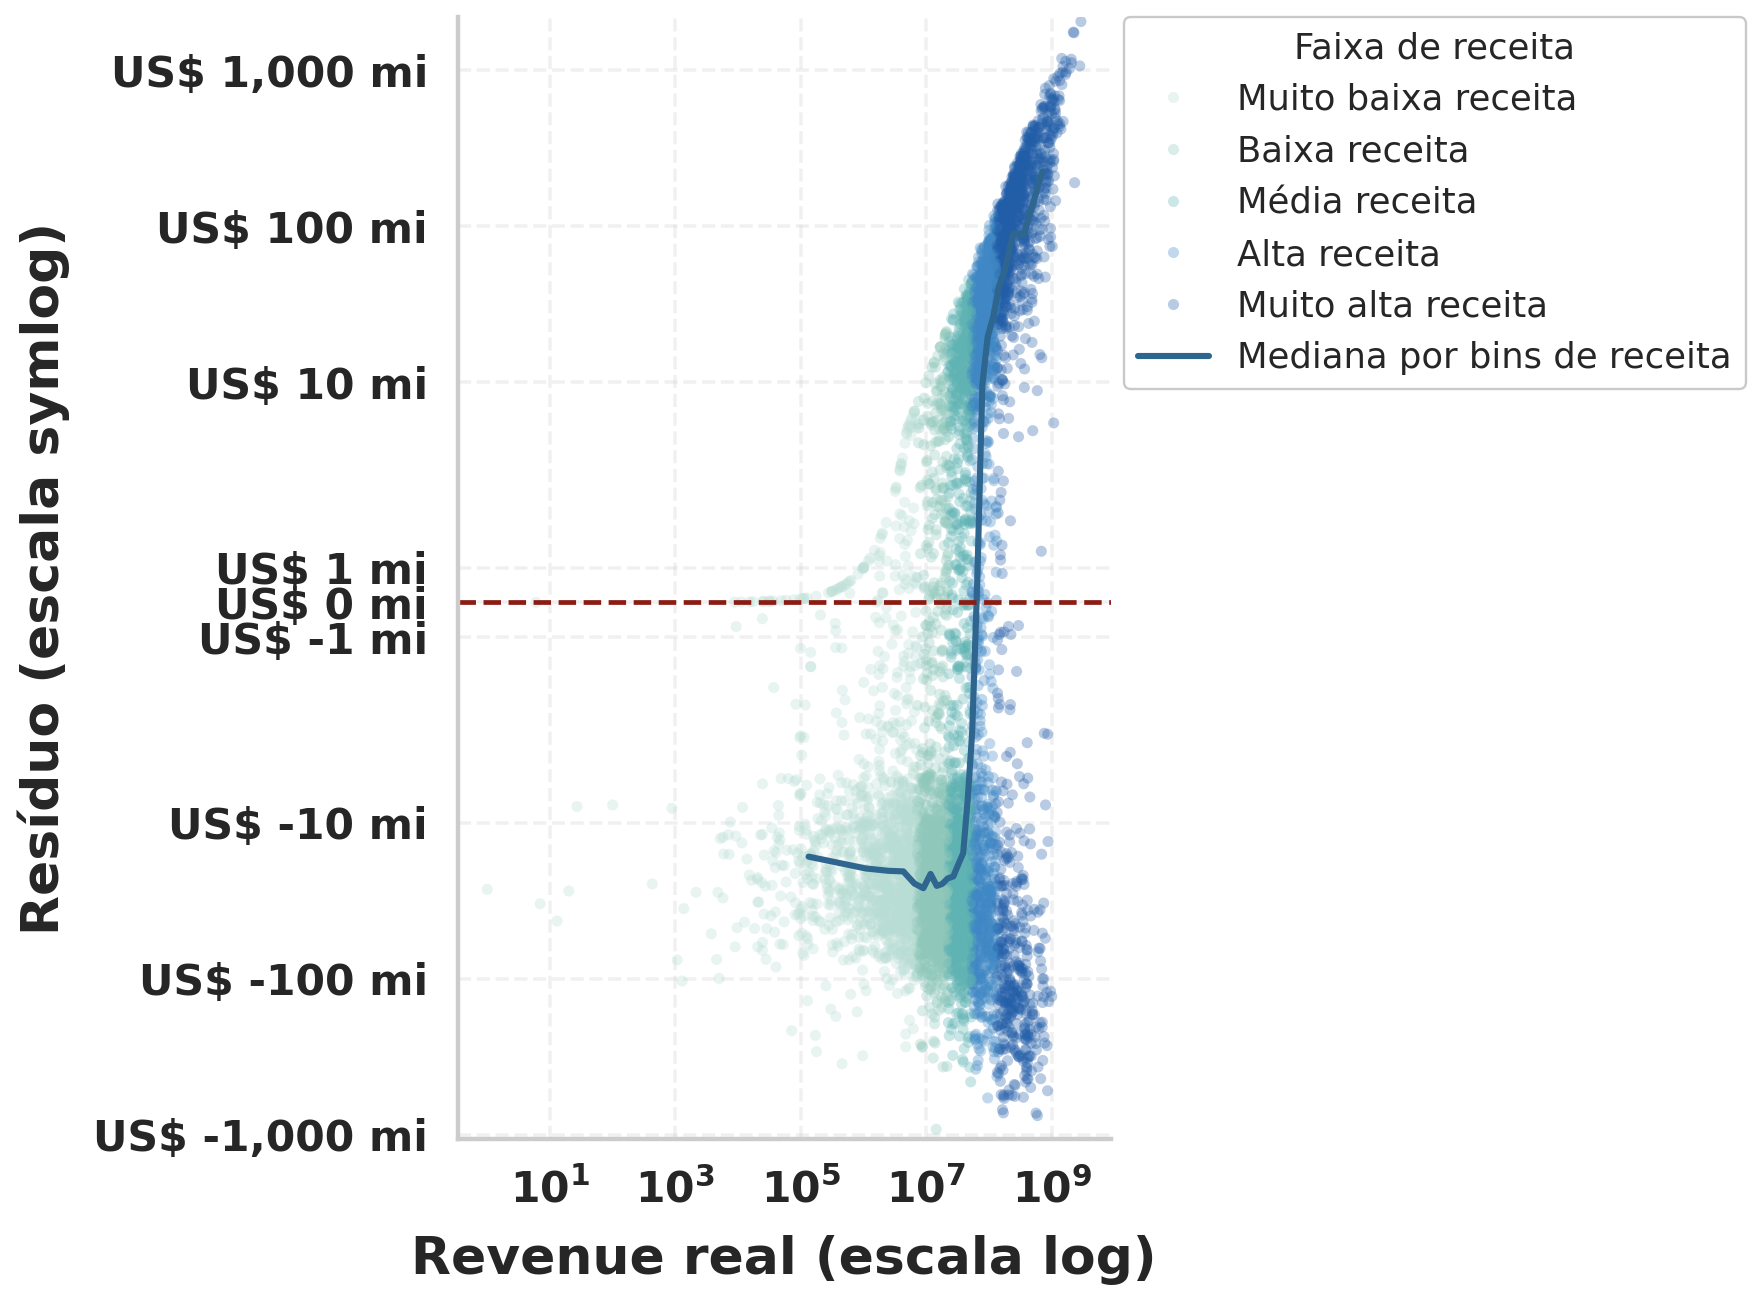

Arquivos de imagem salvos:
- /home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina/trabalho_pratico_1/code/revenue/images/03_analysis_no_transform_mae_por_faixa_receita.png
- /home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina/trabalho_pratico_1/code/revenue/images/03_analysis_no_transform_boxplot_erro_absoluto_por_faixa.png
- /home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina/trabalho_pratico_1/code/revenue/images/03_analysis_no_transform_dispersao_y_true_vs_y_pred.png
- /home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina/trabalho_pratico_1/code/revenue/images/03_analysis_no_transform_residuos_vs_y_true.png


In [14]:
figure_title = 'MAE por faixa de receita'
million_axis = FuncFormatter(millions_formatter)
saved_image_paths = []
band_palette_list = [BAND_PALETTE[label] for label in REVENUE_BAND_LABELS]

apply_article_figure_theme()
plt.figure(figsize=(13, 7.4))
ax = sns.barplot(
    data=band_metrics_raw_df,
    x='faixa_receita',
    y='mae_medio',
    hue='faixa_receita',
    order=REVENUE_BAND_LABELS,
    palette=band_palette_list,
    dodge=False,
    width=0.74,
    edgecolor=PLOT_COLORS['text'],
    linewidth=0.8,
)
if ax.legend_ is not None:
    ax.legend_.remove()
ax.yaxis.set_major_formatter(million_axis)
style_axis(ax, 'Faixa de receita', 'MAE médio', xrotation=15, grid_axis='y')
add_bar_value_labels(ax, band_metrics_raw_df['mae_medio'])
plt.tight_layout()
saved_image_paths.append(
    show_and_save_current_figure(
        f'{NOTEBOOK_IMAGE_PREFIX}_mae_por_faixa_receita',
        notebook_title=figure_title,
    )
)

boxplot_df = error_analysis_df.copy()
boxplot_df['abs_error_mi_plot'] = (boxplot_df['abs_error'] / 1_000_000).clip(lower=1e-3)

figure_title = 'Distribuição do erro absoluto por faixa de receita'
apply_article_figure_theme()
plt.figure(figsize=(13, 7.4))
ax = sns.boxplot(
    data=boxplot_df,
    x='faixa_receita',
    y='abs_error_mi_plot',
    hue='faixa_receita',
    order=REVENUE_BAND_LABELS,
    palette=band_palette_list,
    dodge=False,
    width=0.64,
    linewidth=1.3,
    boxprops={'edgecolor': PLOT_COLORS['text']},
    whiskerprops={'color': PLOT_COLORS['text'], 'linewidth': 1.2},
    capprops={'color': PLOT_COLORS['text'], 'linewidth': 1.2},
    medianprops={'color': PLOT_COLORS['red'], 'linewidth': 2.2},
    flierprops={'marker': 'o', 'markersize': 2.8, 'markerfacecolor': PLOT_COLORS['red'], 'markeredgecolor': 'none', 'alpha': 0.10},
)
if ax.legend_ is not None:
    ax.legend_.remove()
ax.set_yscale('log')
style_axis(
    ax,
    'Faixa de receita',
    'Erro absoluto (US$ mi, escala log)',
    xrotation=15,
    grid_axis='y',
)
plt.tight_layout()
plt.subplots_adjust(left=0.20)
saved_image_paths.append(
    show_and_save_current_figure(
        f'{NOTEBOOK_IMAGE_PREFIX}_boxplot_erro_absoluto_por_faixa',
        notebook_title=figure_title,
    )
)

plot_df = error_analysis_df.copy()
plot_df['y_true_plot'] = plot_df['y_true'].clip(lower=1)
plot_df['y_pred_plot'] = plot_df['y_pred'].clip(lower=1)
plot_min = max(min(plot_df['y_true_plot'].min(), plot_df['y_pred_plot'].min()), 1)
plot_max = max(plot_df['y_true_plot'].max(), plot_df['y_pred_plot'].max())

figure_title = 'Valores reais vs preditos por faixa de receita'
apply_article_figure_theme()
plt.figure(figsize=(10.8, 8.6))
ax = sns.scatterplot(
    data=plot_df,
    x='y_true_plot',
    y='y_pred_plot',
    hue='faixa_receita',
    hue_order=REVENUE_BAND_LABELS,
    palette=BAND_PALETTE,
    alpha=0.38,
    s=22,
    edgecolor='none',
)
ax.plot([plot_min, plot_max], [plot_min, plot_max], linestyle='--', color=PLOT_COLORS['red'], linewidth=2)
ax.set_xscale('log')
ax.set_yscale('log')
style_axis(ax, 'Revenue real (escala log)', 'Revenue predito (escala log)')
legend = ax.legend(title='Faixa de receita', fontsize=ARTICLE_FIGURE_SIZES['legend'], title_fontsize=ARTICLE_FIGURE_SIZES['legend_title'], loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
style_band_legend(legend)
plt.tight_layout()
saved_image_paths.append(
    show_and_save_current_figure(
        f'{NOTEBOOK_IMAGE_PREFIX}_dispersao_y_true_vs_y_pred',
        notebook_title=figure_title,
    )
)

residual_trend_df = (
    plot_df.assign(revenue_bin=pd.qcut(plot_df['y_true_plot'], q=24, duplicates='drop'))
    .groupby('revenue_bin', observed=False)
    .agg(
        y_true_center=('y_true_plot', 'median'),
        residual_median=('residual', 'median'),
    )
    .dropna()
)

figure_title = 'Resíduos em função da receita real por faixa de receita'
apply_article_figure_theme()
plt.figure(figsize=(10.8, 8.0))
ax = sns.scatterplot(
    data=plot_df,
    x='y_true_plot',
    y='residual',
    hue='faixa_receita',
    hue_order=REVENUE_BAND_LABELS,
    palette=BAND_PALETTE,
    alpha=0.32,
    s=22,
    edgecolor='none',
)
ax.plot(
    residual_trend_df['y_true_center'],
    residual_trend_df['residual_median'],
    color=PLOT_COLORS['navy'],
    linewidth=2.6,
    label='Mediana por bins de receita',
)
ax.axhline(0, linestyle='--', color=PLOT_COLORS['red'], linewidth=2)
ax.set_xscale('log')
ax.set_yscale('symlog', linthresh=5_000_000)
ax.yaxis.set_major_formatter(million_axis)
style_axis(ax, 'Revenue real (escala log)', 'Resíduo (escala symlog)')
legend = ax.legend(title='Faixa de receita', fontsize=ARTICLE_FIGURE_SIZES['legend'], title_fontsize=ARTICLE_FIGURE_SIZES['legend_title'], loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
style_band_legend(legend)
plt.tight_layout()
saved_image_paths.append(
    show_and_save_current_figure(
        f'{NOTEBOOK_IMAGE_PREFIX}_residuos_vs_y_true',
        notebook_title=figure_title,
    )
)

print('Arquivos de imagem salvos:')
for image_path in saved_image_paths:
    print(f'- {image_path}')

# **Importância por Permutação**

A importância por permutação é calculada com o modelo selecionado em cada partição e agregada na visualização final. Essa abordagem oferece uma leitura mais robusta da relevância dos atributos, pois mede o impacto real de embaralhar cada feature sobre o desempenho observado fora do treino.


In [15]:
all_perm_importances = []

for idx, (model, X_test_fold, y_test_model_fold) in enumerate(all_best_models):
    result = permutation_importance(
        model,
        X_test_fold,
        y_test_model_fold,
        scoring='neg_mean_squared_error',
        n_repeats=10,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

    perm_df = pd.DataFrame({
        'feature': X_test_fold.columns,
        'importance_mean': result.importances_mean,
        'importance_std': result.importances_std
    }).sort_values(by='importance_mean', ascending=False)

    perm_df['fold'] = idx
    all_perm_importances.append(perm_df)

final_perm_df = pd.concat(all_perm_importances, ignore_index=True)

Figura: Importância média das features por permutação (XGBoost Regressor | Sem transformação)


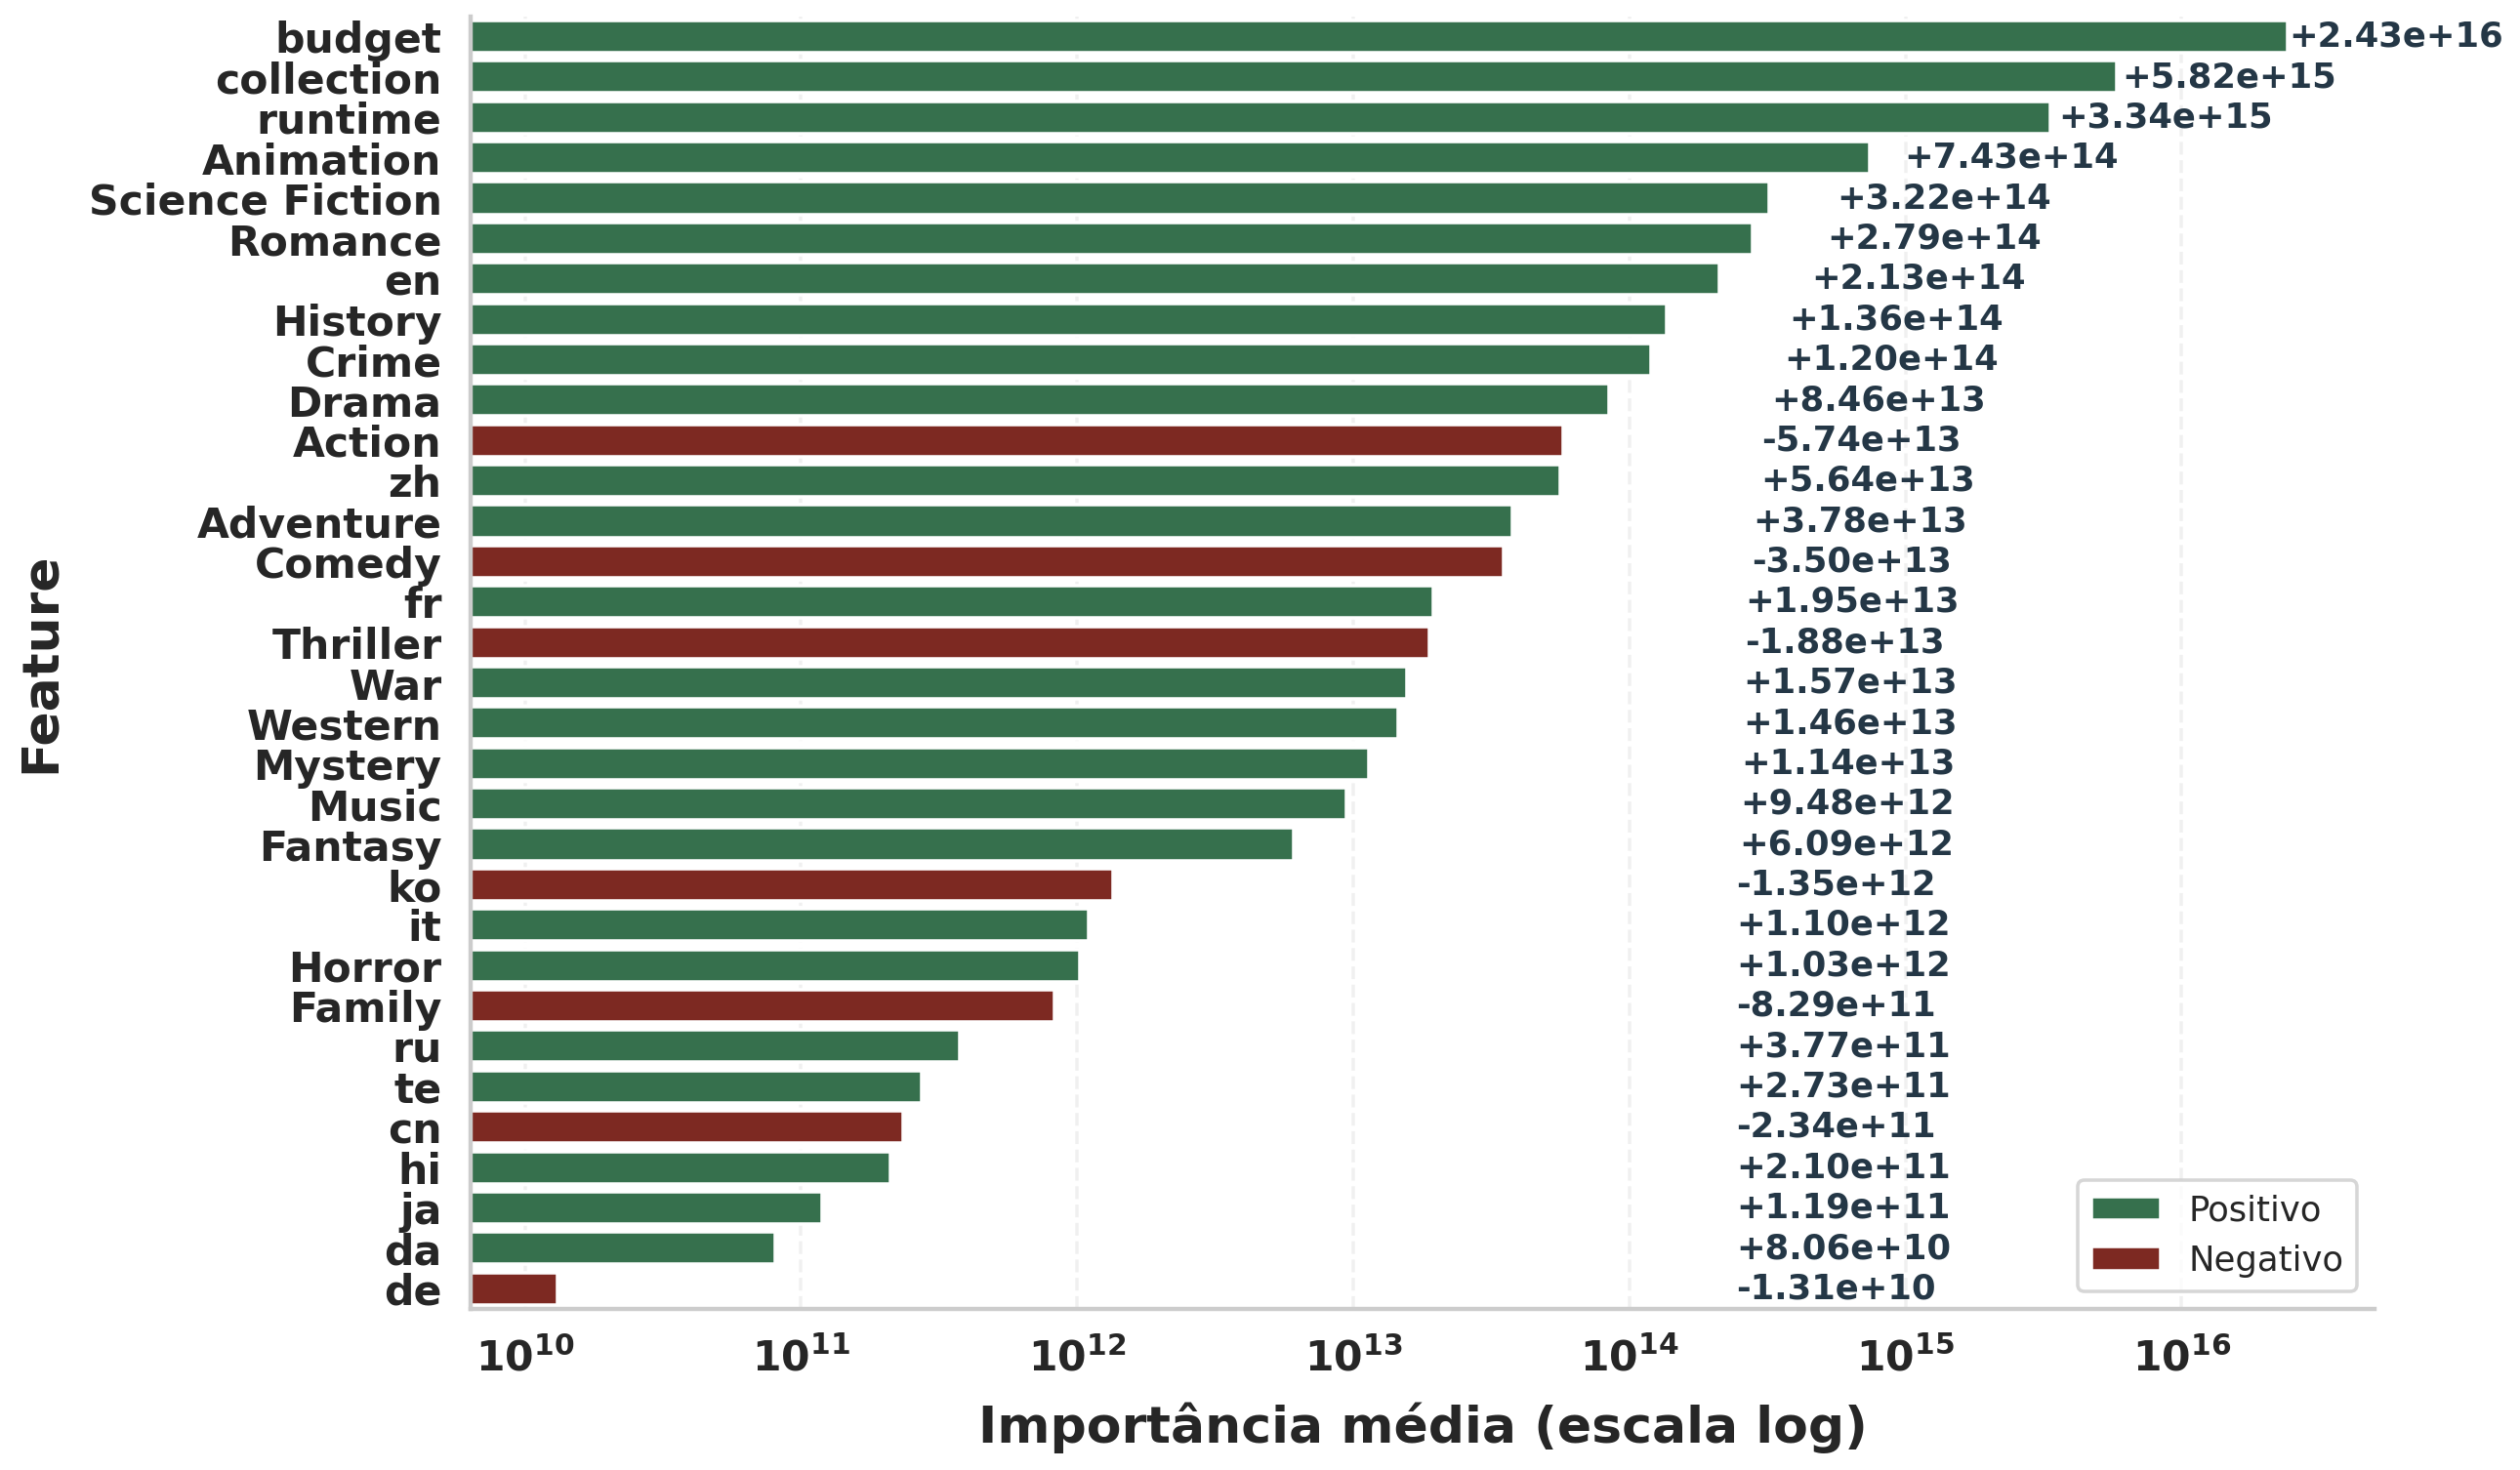

PosixPath('/home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina/trabalho_pratico_1/code/revenue/images/03_analysis_no_transform_importancia_media_das_features_por_permutacao.png')

In [16]:
avg_importance = final_perm_df.groupby('feature')['importance_mean'].mean().sort_values(ascending=False)

df = pd.DataFrame({
    'Feature': avg_importance.index,
    'Importancia': avg_importance.values,
    'Signo': ['Positivo' if v >= 0 else 'Negativo' for v in avg_importance.values]
})
df['Feature'] = df['Feature'].replace('belongs_to_collection', 'collection')
df = df[df['Importancia'] != 0].copy()
df['ImportanciaAbs'] = df['Importancia'].abs().clip(lower=1e-12)
df = df.sort_values('ImportanciaAbs', ascending=False)

palette = {'Positivo': '#2c7a4b', 'Negativo': '#8c1c13'}

figure_title = f'Importância média das features por permutação ({best_model_name} | {best_target_name})'
apply_article_figure_theme()
plt.figure(figsize=(15.5, 9.2))
ax = sns.barplot(data=df, x='ImportanciaAbs', y='Feature', hue='Signo', palette=palette, dodge=False)

plt.xlabel('Importância média (escala log)', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)
plt.ylabel('Feature', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)
ax.tick_params(axis='x', labelsize=ARTICLE_FIGURE_SIZES['tick'])
ax.tick_params(axis='y', labelsize=ARTICLE_FIGURE_SIZES['tick'])
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('semibold')
plt.grid(axis='x', linestyle='--', alpha=0.28)

ax.legend(title='', fontsize=ARTICLE_FIGURE_SIZES['legend'], loc='lower right')
ax.set_xscale('log')

max_val = df['ImportanciaAbs'].max()
for i, row in enumerate(df.itertuples(index=False)):
    sign = '+' if row.Importancia >= 0 else '-'
    ax.text(
        row.ImportanciaAbs + 0.01 * max_val,
        i,
        f"{sign}{row.ImportanciaAbs:.2e}",
        color='#243746',
        va='center',
        ha='left',
        fontsize=ARTICLE_FIGURE_SIZES['annotation_small'],
        fontweight='semibold'
    )
sns.despine(ax=ax)

plt.tight_layout()
show_and_save_current_figure(
    f'{NOTEBOOK_IMAGE_PREFIX}_importancia_media_das_features_por_permutacao',
    notebook_title=figure_title,
)